In [1]:
# !pip install -q -U segmentation-models-pytorch albumentations > /dev/null

In [2]:
# pip install torch torchvision timm segmentation-models

In [3]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import albumentations as album
from albumentations.pytorch import ToTensorV2
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from tqdm import tqdm


c:\PythonProjects\plant_disease_class\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DATA_DIR = 'C:/PythonProjects/plant_disease_class/leaf_segmentation/leaf_disease_segmentation'
ORIG_DATA_DIR = os.path.join(DATA_DIR, 'orig_data')
AUG_DATA_DIR = os.path.join(DATA_DIR, 'aug_data')

train_images = os.path.join(ORIG_DATA_DIR, 'train_images')
train_masks = os.path.join(ORIG_DATA_DIR, 'train_masks')
valid_images = os.path.join(ORIG_DATA_DIR, 'valid_images')
valid_masks = os.path.join(ORIG_DATA_DIR, 'valid_masks')

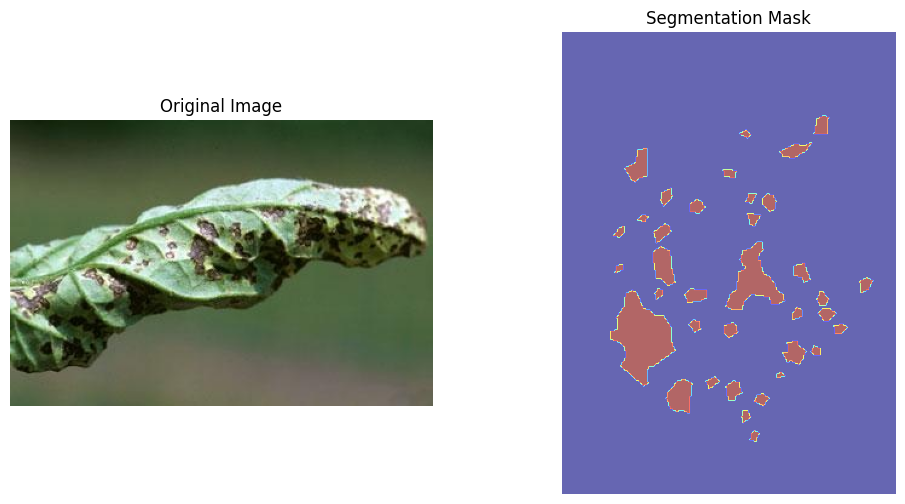

In [5]:
image_path = "C:/PythonProjects/plant_disease_class/leaf_segmentation/leaf_disease_segmentation/aug_data/train_images/00002_0.jpg"
mask_path = "C:/PythonProjects/plant_disease_class/leaf_segmentation/leaf_disease_segmentation/aug_data/train_masks/00000_2.png"

image = Image.open(image_path)
mask = Image.open(mask_path)

image_np = np.array(image)
mask_np = np.array(mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image_np)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask_np, cmap="jet", alpha=0.6) 
axes[1].set_title("Segmentation Mask")
axes[1].axis("off")

plt.show()

In [6]:
class_names = ['background', 'affected']
class_rgb_values = [[0, 0, 0], [128, 0, 0]]
select_class_rgb_values = np.array(class_rgb_values)


# One-hot encoding function
def one_hot_encode(label, label_values):
    semantic_map = [(np.all(label == color, axis=-1)) for color in label_values]
    return np.stack(semantic_map, axis=-1)
    
# Reverse one-hot encoding
def reverse_one_hot(image):
    return np.argmax(image, axis=-1)

def colour_code_segmentation(image, label_values):
    image = np.clip(image, 0, len(label_values)-1).astype(int)
    colour_codes = np.array(label_values)
    return colour_codes[image]

In [7]:
IMG_SIZE = 224

In [8]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, images_dir, masks_dir, class_rgb_values=None, augmentation=None, preprocessing=None):
        self.image_paths = sorted([os.path.join(images_dir, img) for img in os.listdir(images_dir)])
        self.mask_paths = sorted([os.path.join(masks_dir, img) for img in os.listdir(masks_dir)])
        self.class_rgb_values = class_rgb_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing
        
    def __getitem__(self, idx):
        image = cv2.cvtColor(cv2.imread(self.image_paths[idx]), cv2.COLOR_BGR2RGB)
        mask = cv2.cvtColor(cv2.imread(self.mask_paths[idx]), cv2.COLOR_BGR2RGB)
        
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        
        if self.augmentation:
            augmented = self.augmentation(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']
        
        if self.class_rgb_values is not None:
            mask = one_hot_encode(mask, self.class_rgb_values)
        
        if self.preprocessing:
            processed = self.preprocessing(image=image, mask=mask)
            image, mask = processed['image'], processed['mask']
      
        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image.transpose(2, 0, 1)).float()
        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).float()
            
        return image, mask
    
    def __len__(self):
        return len(self.image_paths)

def get_training_augmentation():
    return album.Compose([
        album.OneOf([
            album.HorizontalFlip(p=1),
            album.VerticalFlip(p=1),
            album.RandomRotate90(p=1)
        ], p=0.75)
    ])

def get_validation_augmentation():
    return album.Compose([
        album.Resize(IMG_SIZE,IMG_SIZE, always_apply=True)  
    ])

def to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')

import albumentations as album
from albumentations.pytorch import ToTensorV2

def get_preprocessing(preprocessing_fn=None):
    transforms_list = []
    
    if preprocessing_fn:
        transforms_list.append(album.Lambda(image=preprocessing_fn))

    transforms_list.extend([
        album.Normalize(), 
        ToTensorV2()        
    ])
    
    return album.Compose(transforms_list)


In [9]:
train_dataset = PlantDiseaseDataset(train_images, train_masks, augmentation=get_training_augmentation(), preprocessing=get_preprocessing(), class_rgb_values=select_class_rgb_values)
valid_dataset = PlantDiseaseDataset(valid_images, valid_masks, augmentation=get_validation_augmentation(), preprocessing=get_preprocessing(), class_rgb_values=select_class_rgb_values)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False, num_workers=2)

C:\Users\admin\AppData\Local\Temp\ipykernel_22436\424752616.py:48: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(IMG_SIZE,IMG_SIZE, always_apply=True)


In [10]:
from transformers import SegformerForSemanticSegmentation, SegformerConfig, AutoModelForImageSegmentation, SegformerForImageClassification
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import matplotlib.pyplot as plt
from tqdm import tqdm
import ssl
import urllib.request

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation, SegformerConfig

class ViTSegmentationModel(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(ViTSegmentationModel, self).__init__()
        
        if pretrained:
            self.model = SegformerForSemanticSegmentation.from_pretrained(
                "nvidia/segformer-b0-finetuned-ade-512-512",
                num_labels=150,  
                ignore_mismatched_sizes=True
            )
            
            in_features = self.model.decode_head.classifier.in_channels  
            self.model.decode_head.classifier = nn.Conv2d(in_features, num_classes, kernel_size=1)
        else:
            config = SegformerConfig(
                num_labels=num_classes,
                hidden_sizes=[32, 64, 160, 256],
                num_encoder_blocks=[2, 2, 2, 2]
            )
            self.model = SegformerForSemanticSegmentation(config)

    def forward(self, x):
        logits = self.model(pixel_values=x).logits
        logits = F.interpolate(logits, size=(224, 224), mode='bilinear', align_corners=False)
        return logits


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=False):
        super(UNetBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5) if dropout else None
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        if self.dropout:
            x = self.dropout(x)
        x_pool = self.pool(x)
        return x, x_pool  # возвращаем выход сэмплированного блока и его "сжатую" версию

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels, base_filters=64):
        super(UNet, self).__init__()
        
        # Блоки кодировщика
        self.enc1 = UNetBlock(in_channels, base_filters)
        self.enc2 = UNetBlock(base_filters, base_filters * 2)
        self.enc3 = UNetBlock(base_filters * 2, base_filters * 4)
        self.enc4 = UNetBlock(base_filters * 4, base_filters * 8)

        # Блок кодировщика - на самой нижней "плоскости"
        self.bottleneck = UNetBlock(base_filters * 8, base_filters * 16, dropout=True)

        # Блоки декодировщика
        self.dec4 = UNetBlock(base_filters * 16, base_filters * 8)
        self.dec3 = UNetBlock(base_filters * 8, base_filters * 4)
        self.dec2 = UNetBlock(base_filters * 4, base_filters * 2)
        self.dec1 = UNetBlock(base_filters * 2, base_filters)

        # Выходной слой
        self.final_conv = nn.Conv2d(base_filters, out_channels, kernel_size=1)

    def forward(self, x):
        # Кодировщик
        enc1_out, enc1_pool = self.enc1(x)
        enc2_out, enc2_pool = self.enc2(enc1_pool)
        enc3_out, enc3_pool = self.enc3(enc2_pool)
        enc4_out, enc4_pool = self.enc4(enc3_pool)

        # Боттлнек
        bottleneck_out, bottleneck_pool = self.bottleneck(enc4_pool)

        # Декодировщик (с пропусками связи)
        dec4_out = self.dec4(bottleneck_out)[0]
        dec3_out = self.dec3(dec4_out + enc4_out)[0]
        dec2_out = self.dec2(dec3_out + enc3_out)[0]
        dec1_out = self.dec1(dec2_out + enc2_out)[0]

        # Выходной слой
        final_out = self.final_conv(dec1_out + enc1_out)

        return final_out

class UNetSegmentationModel(nn.Module):
    def __init__(self, num_classes=2, pretrained=False, model_dir=None):
        super(UNetSegmentationModel, self).__init__()

        if pretrained:
            raise NotImplementedError("Pretrained models are not yet supported for UNet in this example")

        # Создаем UNet модель
        self.model = UNet(in_channels=3, out_channels=num_classes)

    def forward(self, x):
        logits = self.model(x)
        logits = F.interpolate(logits, size=(48, 48), mode='bilinear', align_corners=False)
        return logits


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Используем UNetSegmentationModel с параметром pretrained=False
model = UNetSegmentationModel(
    num_classes=2, 
    pretrained=False,  # UNet не использует предобученные модели в нашем примере
)

model.to(device)


UNetSegmentationModel(
  (model): UNet(
    (enc1): UNetBlock(
      (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (enc2): UNetBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (enc3): UNetBlock(
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (enc4): UNe

In [14]:
class DiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()
        
    def forward(self, inputs, targets, smooth=1):
        inputs = F.softmax(inputs, dim=1)
        
        if len(targets.shape) == 3:
            targets = F.one_hot(targets, num_classes=inputs.shape[1]).permute(0, 3, 1, 2).float()
      
        inputs_flat = inputs.view(inputs.size(0), inputs.size(1), -1)
        targets_flat = targets.view(targets.size(0), inputs.size(1), -1)
        
        intersection = (inputs_flat * targets_flat).sum(2)
        union = inputs_flat.sum(2) + targets_flat.sum(2)
        
        dice = (2. * intersection + smooth) / (union + smooth)
        
        dice = dice.mean(0).mean()
        
        return 1 - dice

class CombinedLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(CombinedLoss, self).__init__()
        self.ce_loss = nn.CrossEntropyLoss(weight=weight)
        self.dice_loss = DiceLoss()
        
    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        dice_loss = self.dice_loss(inputs, targets)
        return ce_loss + dice_loss
    


In [15]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

# Training function
def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, num_epochs=50, patience=10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    os.makedirs('checkpoints', exist_ok=True)
    os.makedirs('results', exist_ok=True)
    
    best_loss = float('inf')
    best_dice = 0
    patience_counter = 0
    train_losses, valid_losses = [], []
    train_dices, valid_dices = [], []

    dice_metric = DiceLoss()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        
        # Training phase
        print("AAAAAAAAAAAAAAAAAAAAAAAAAAA 1 ")
        model.train()
        train_loss = 0.0
        train_dice = 0.0

        print("AAAAAAAAAAAAAAAAAAAAAAAAAAA 2 ", train_loss, train_dice)
        
        train_pbar = tqdm(train_loader, desc='Training')

        print("AAAAAAAAAAAAAAAAAAAAAAAAAAA 3 ", train_loader)
        
        for images, masks in train_pbar:
            images = images.to(device)

            print("AAAAAAAAAAAAAAAAAAAAAAAAAAA 4 ")
    
            masks = masks.permute(0, 3, 1, 2).to(torch.float32)  # Convert from (B, H, W, C) -> (B, C, H, W)
            masks = torch.argmax(masks, dim=1)  # Convert from (B, C, H, W) to (B, H, W)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, masks)  # Compute loss
            
            loss.backward()  # Backpropagation
            optimizer.step()  # Update model parameters

            # Compute Dice score
            with torch.no_grad():
                dice_score = 1 - dice_metric(outputs, masks)
            
            # Update metrics
            train_loss += loss.item() * images.size(0)
            train_dice += dice_score.item() * images.size(0)

            train_pbar.set_postfix({'loss': loss.item(), 'dice': dice_score.item()})

    
        scheduler.step()

        train_loss /= len(train_loader.dataset)
        train_dice /= len(train_loader.dataset)
        train_losses.append(train_loss)
        train_dices.append(train_dice)

        model.eval()
        valid_loss = 0.0
        valid_dice = 0.0
        valid_pbar = tqdm(valid_loader, desc='Validation')


        print("AAAAAAAAAAAAAAAAAAAAAAAAAAA 5")


        with torch.no_grad():
            for images, masks in valid_pbar:
                images = images.to(device)

                masks = masks.permute(0, 3, 1, 2).to(torch.float32)
                masks = torch.argmax(masks, dim=1)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)
                dice_score = 1 - dice_metric(outputs, masks)

                valid_loss += loss.item() * images.size(0)
                valid_dice += dice_score.item() * images.size(0)
                valid_pbar.set_postfix({'loss': loss.item(), 'dice': dice_score.item()})

        valid_loss /= len(valid_loader.dataset)
        valid_dice /= len(valid_loader.dataset)
        valid_losses.append(valid_loss)
        valid_dices.append(valid_dice)

        print(f'Train Loss: {train_loss:.4f}, Dice: {train_dice:.4f}')
        print(f'Valid Loss: {valid_loss:.4f}, Dice: {valid_dice:.4f}')
  
        if valid_loss < best_loss:
            best_loss = valid_loss
            torch.save(model.state_dict(), 'checkpoints/best_loss_model.pt')
            patience_counter = 0
        else:
            patience_counter += 1

        if valid_dice > best_dice:
            best_dice = valid_dice
            torch.save(model.state_dict(), 'checkpoints/best_dice_model.pt')

        if patience_counter >= patience:
            print(f'Early stopping after {epoch+1} epochs')
            break

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(valid_losses, label='Valid Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_dices, label='Train Dice')
    plt.plot(valid_dices, label='Valid Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.legend()

    plt.tight_layout()
    plt.savefig('results/training_metrics.png')

    return model


In [16]:
criterion = CombinedLoss()

# Параметры модели UNet
optimizer = torch.optim.AdamW([
    {'params': model.model.enc1.parameters(), 'lr': 1e-5},  # Параметры первого блока кодировщика
    {'params': model.model.enc2.parameters(), 'lr': 1e-5},  # Параметры второго блока кодировщика
    {'params': model.model.enc3.parameters(), 'lr': 1e-5},  # Параметры третьего блока кодировщика
    {'params': model.model.enc4.parameters(), 'lr': 1e-5},  # Параметры четвертого блока кодировщика
    {'params': model.model.dec1.parameters(), 'lr': 1e-4},  # Параметры первого блока декодировщика
    {'params': model.model.dec2.parameters(), 'lr': 1e-4},  # Параметры второго блока декодировщика
    {'params': model.model.dec3.parameters(), 'lr': 1e-4},  # Параметры третьего блока декодировщика
    {'params': model.model.dec4.parameters(), 'lr': 1e-4},  # Параметры четвертого блока декодировщика
], weight_decay=1e-4)

scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,  
    T_mult=2,  
    eta_min=1e-6  
)


In [17]:
trained_model = train_model(
        model,
        train_loader,
        valid_loader,
        criterion,
        optimizer,
        scheduler,
        num_epochs=30,
        patience=5  
    )

Epoch 1/30
AAAAAAAAAAAAAAAAAAAAAAAAAAA 1 
AAAAAAAAAAAAAAAAAAAAAAAAAAA 2  0.0 0.0


Training:   0%|          | 0/32 [00:00<?, ?it/s]

AAAAAAAAAAAAAAAAAAAAAAAAAAA 3  Training:   0%|          | 0/32 [00:00<?, ?it/s]


In [ ]:
def visualize(**images):
    n_images = len(images)
    plt.figure(figsize=(20,8))
    for idx, (name, image) in enumerate(images.items()):
        plt.subplot(1, n_images, idx + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(name.replace('_',' ').title(), fontsize=20)
    
        if name == 'original_image' and image.shape[0] == 3:  
            plt.imshow(image.transpose(1, 2, 0))
        else:
            plt.imshow(image)
    plt.show()
    
def class_index_to_rgb(mask, class_rgb_values):
    if len(mask.shape) == 3 and mask.shape[0] == 2: 
        mask = np.argmax(mask, axis=0)
    
    rgb_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for idx, color in enumerate(class_rgb_values):
        rgb_mask[mask == idx] = color
    return rgb_mask

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

def predict_and_save(model, dataset, index=0, save_path="predictions/"):
    os.makedirs(save_path, exist_ok=True)
    model.eval()
    
    image, gt_mask = dataset[index]
    
    if isinstance(image, torch.Tensor):  
        image_np = image.cpu().numpy()
    else:
        image_np = image.copy()
    
    if len(image_np.shape) == 3 and image_np.shape[0] == 3:
        image_vis = image_np.transpose(1, 2, 0).copy()
    else:
        image_vis = image_np.copy()
    
    min_val = float(image_vis.min())
    max_val = float(image_vis.max())
    
    if min_val < 0 or max_val > 1:
        image_vis = (image_vis - min_val) / (max_val - min_val)
    
    image_vis = (image_vis * 255).astype(np.uint8)
    
    if isinstance(image, np.ndarray):
        x_tensor = torch.from_numpy(image).unsqueeze(0).to(device)
    else:
        x_tensor = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_mask = model(x_tensor).cpu().squeeze().numpy()
        pred_mask = np.argmax(pred_mask, axis=0)
    
    if isinstance(gt_mask, torch.Tensor):
        gt_mask = gt_mask.cpu().numpy()
    
    if len(gt_mask.shape) == 3:
        if gt_mask.shape[0] in [1, 2, 3]:
            if gt_mask.shape[0] > 1:
                gt_mask_indices = np.argmax(gt_mask, axis=0)
            else:
                gt_mask_indices = gt_mask[0]
        else:
            if gt_mask.shape[2] > 1:
                gt_mask_indices = np.argmax(gt_mask, axis=2)
            else:
                gt_mask_indices = gt_mask[:, :, 0]
    else:
        gt_mask_indices = gt_mask
    
    height, width = gt_mask_indices.shape
    
    gt_mask_rgb = np.zeros((height, width, 3), dtype=np.uint8)
    pred_mask_rgb = np.zeros((height, width, 3), dtype=np.uint8)
    
    for h in range(height):
        for w in range(width):
            gt_idx = int(gt_mask_indices[h, w])
            pred_idx = int(pred_mask[h, w])
            
            if 0 <= gt_idx < len(class_rgb_values):
                gt_mask_rgb[h, w] = class_rgb_values[gt_idx]
            
            if 0 <= pred_idx < len(class_rgb_values):
                pred_mask_rgb[h, w] = class_rgb_values[pred_idx]
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image_vis)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask_rgb)
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_rgb)
    plt.title("Predicted Mask")
    plt.axis("off")
    
    save_filepath = os.path.join(save_path, f"prediction_{index}.png")
    plt.savefig(save_filepath)
    plt.show()

In [ ]:
test_dataset = PlantDiseaseDataset(
    valid_images, valid_masks,
    augmentation=get_validation_augmentation(), 
    preprocessing=get_preprocessing(), 
    class_rgb_values=select_class_rgb_values
)

model.load_state_dict(torch.load('checkpoints/best_dice_model.pt', map_location=device, weights_only=True))
model.to(device)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


for i in range(10):
    random_idx = np.random.randint(0, len(test_dataset)) 
    predict_and_save(model, test_dataset, index=random_idx)